In [2]:
import numpy as np
import matplotlib.pyplot as plt
print(np.arange(10))

[0 1 2 3 4 5 6 7 8 9]


[-9.400e+01 -8.900e+01 -8.400e+01 -7.800e+01 -7.200e+01 -6.700e+01
 -6.400e+01 -6.200e+01 -6.200e+01 -6.200e+01 -6.300e+01 -6.400e+01
 -6.500e+01 -6.600e+01 -6.700e+01 -6.700e+01 -6.600e+01 -6.600e+01
 -6.500e+01 -6.400e+01 -6.300e+01 -6.200e+01 -6.100e+01 -6.000e+01
 -6.000e+01 -5.900e+01 -5.900e+01 -5.900e+01 -5.800e+01 -5.700e+01
 -5.500e+01 -5.300e+01 -5.100e+01 -5.000e+01 -4.900e+01 -4.900e+01
 -4.900e+01 -5.200e+01 -5.500e+01 -5.900e+01 -6.300e+01 -6.800e+01
 -7.200e+01 -7.500e+01 -7.700e+01 -7.900e+01 -7.900e+01 -7.900e+01
 -7.800e+01 -7.700e+01 -7.600e+01 -7.500e+01 -7.500e+01 -7.500e+01
 -7.700e+01 -7.800e+01 -8.100e+01 -8.300e+01 -8.600e+01 -8.900e+01
 -9.100e+01 -9.300e+01 -9.300e+01 -9.200e+01 -9.000e+01 -8.600e+01
 -8.100e+01 -7.500e+01 -7.000e+01 -6.500e+01 -6.200e+01 -6.100e+01
 -6.300e+01 -6.700e+01 -7.200e+01 -7.900e+01 -8.500e+01 -9.000e+01
 -9.400e+01 -9.500e+01 -9.300e+01 -8.900e+01 -8.400e+01 -7.800e+01
 -7.300e+01 -6.800e+01 -6.600e+01 -6.500e+01 -6.600e+01 -6.900

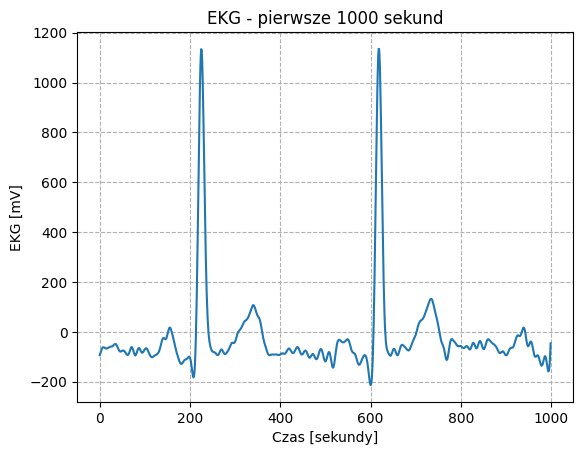

In [40]:
dane_file = '2025-2025-11-05-09-27-25.csv'
dane = np.genfromtxt(dane_file, delimiter=',', skip_header=1)
HR=dane[:,1]
HR_short=HR[0:1000]
plt.plot(HR_short)
plt.title('EKG - pierwsze 1000 sekund')
plt.xlabel('Czas [sekundy]')
plt.ylabel('EKG [mV]')
plt.grid(True, linestyle='--')
plt.show()

Średnie tętno (NeuroKit2): 100.12 BPM


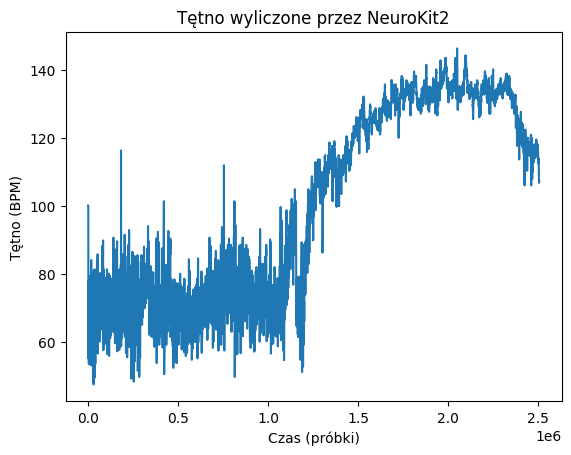

In [73]:
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
dane_file = 'ekg_2025-10-30-2025-09-28-10.csv'
dane = np.genfromtxt(dane_file, delimiter=',', skip_header=1)
HR=dane[:,1]
fs = 500
ecg_signal = HR  # Zakładamy, że HR to surowy sygnał ECG (choć w rzeczywistości może być to już przetworzony sygnał tętna)

# Przetwarzanie sygnału - automatyczna filtracja, czyszczenie i ekstrakcja cech
signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)

# `signals` to ramka danych (pandas DataFrame), która zawiera wyliczone tętno punkt po punkcie
hr_signal = signals["ECG_Rate"]

# Wyciągnięcie średniego tętna z całego zapisu (pomijając wartości NaN, które mogą pojawić się na początku)
mean_hr = np.nanmean(hr_signal)

print(f"Średnie tętno (NeuroKit2): {mean_hr:.2f} BPM")
plt.plot(hr_signal)
plt.title("Tętno wyliczone przez NeuroKit2")
plt.xlabel("Czas (próbki)")
plt.ylabel("Tętno (BPM)")
plt.show()

In [ ]:
import neurokit2 as nk
dane_file = 'EKG_2025-10-30-2025-09-28-10.csv'
dane = np.genfromtxt(dane_file, delimiter=',', skip_header=1)
HR=dane[:,1]
fs = 500
ecg_signal = HR  # Zakładamy, że HR to surowy sygnał ECG (choć w rzeczywistości może być to już przetworzony sygnał tętna)

# Przetwarzanie sygnału - automatyczna filtracja, czyszczenie i ekstrakcja cech
signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)

# `signals` to ramka danych (pandas DataFrame), która zawiera wyliczone tętno punkt po punkcie
hr_signal = signals["ECG_Rate"]


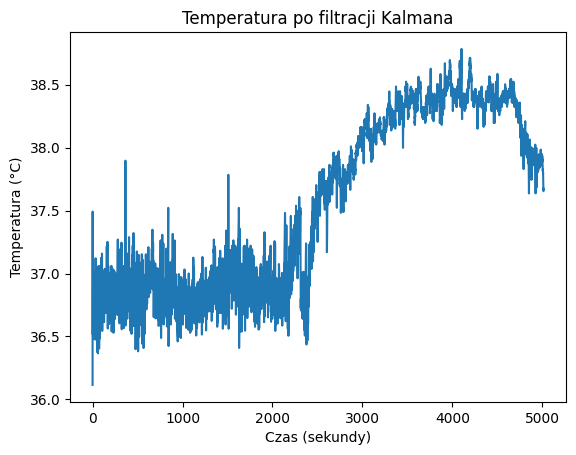

In [74]:

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
time = np.arange(len(hr_signal)) / fs  # Czas w sekundach
b0=-7887.1
b1=384.4286
b2=-4.5714
ct0=36.11
v0=0
a1=1
a0=0
y=0.022
s=18.88
f=norm.rvs(0,y)
ctm1=ct0
vm1=v0

def filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_signal):
    v_list=[]
    ct_list=[]
    for i in range(len(hr_signal)):
        ctp=a1*ctm1+a0
        vp=a1**2*vm1+y**2
        f=np.random.normal(0,y)
        c=2*b2*ctp+b1
        k=(vp*c)/(vp*c**2+s**2)
        ct=ctp+k*(hr_signal[i]-(b2*ctp**2+b1*ctp+b0))
        v=(1-k*c)*vp
        ct_list.append(ct)
        v_list.append(v)
        ctm1=ct
        vm1=v
    return ct_list, v_list
ct_list, v_list=filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_signal)
plt.plot(time, ct_list)
plt.title("Temperatura po filtracji Kalmana")
plt.xlabel("Czas (sekundy)")
plt.ylabel("Temperatura (°C)")
plt.show()

GS

In [ ]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.stats import norm
# ==========================================
# 1. PARAMETRY STARTOWE I DANE WEJŚCIOWE
# ==========================================

# Ręcznie przypisany czas rozpoczęcia badania EKG
start_time = {
    'hour': 9,
    'minute': 27,
    'second': 25
}

# Częstotliwość próbkowania EKG
fs = 500  

# Symulacja Twoich danych EKG (zwykła lista Python)
dane_file = '2025-2025-11-05-09-27-25.csv'
dane = np.genfromtxt(dane_file, delimiter=',', skip_header=1)
ecg_signal = dane[:,1]


# ==========================================
# 2. PRZETWARZANIE TEMPERATURY (Plik .csv)
# ==========================================

# Wczytanie CSV (usecols=[0,1] ignoruje dodatkowy przecinek na końcu linii)
df_temp = pd.read_csv('2025-11-05_09-05-29+1_WYQKBC_temperature_GS.csv', names=['surowy_czas', 'temperatura'], usecols=[0, 1])
df_temp['surowy_czas'] = df_temp['surowy_czas'].str.strip()

# Konwersja czasu temperatury na obiekty Datetime (używamy utc=True dla obsługi strefy +1)
df_temp['datetime'] = pd.to_datetime(df_temp['surowy_czas'], utc=True)

# Definiujemy punkt zero (t0) jako początek pomiaru temperatury
t0 = df_temp['datetime'].iloc[0]

# Obliczamy czas względny w sekundach dla temperatury
df_temp['czas_sekundy'] = (df_temp['datetime'] - t0).dt.total_seconds()

# ==========================================
# 3. SYNCHRONIZACJA I PRZETWARZANIE EKG
# ==========================================

# Wyciągamy datę (np. "2025-11-05") z pierwszego wiersza temperatury
pierwszy_wiersz_czas = df_temp['surowy_czas'].iloc[0]
data_part = pierwszy_wiersz_czas.split('T')[0]

# Wyciągamy końcówkę strefy czasowej (np. "+1" lub "-02:00")
tz_suffix = ""
if 'T' in pierwszy_wiersz_czas:
    time_part = pierwszy_wiersz_czas.split('T')[1]
    if '+' in time_part:
        tz_suffix = '+' + time_part.split('+')[-1]
    elif '-' in time_part:
        tz_suffix = '-' + time_part.split('-')[-1]

# Budujemy pełny ciąg tekstowy ISO dla startu EKG na podstawie słownika start_time
ecg_start_iso = f"{data_part}T{start_time['hour']:02d}:{start_time['minute']:02d}:{start_time['second']:02d}{tz_suffix}"
ecg_start_datetime = pd.to_datetime(ecg_start_iso, utc=True)

# Obliczamy przesunięcie: w której sekundzie (względem temperatury) wystartowało EKG
ecg_offset_seconds = (ecg_start_datetime - t0).total_seconds()

# Generujemy oś czasu dla EKG w sekundach (co 1/500 sekundy od momentu przesunięcia)
liczba_probek_ekg = len(ecg_signal)
ecg_times = ecg_offset_seconds + (np.arange(liczba_probek_ekg) / fs)


# Przetwarzanie sygnału - automatyczna filtracja, czyszczenie i ekstrakcja cech
signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)

# `signals` to ramka danych (pandas DataFrame), która zawiera wyliczone tętno punkt po punkcie
hr_signal = signals["ECG_Rate"]
rozmiar_okna = 30000

# 1. Filtr medianowy - rewelacyjnie usuwa ostre, pojedyncze "szpilki" z wykresu
# Parametr center=True sprawia, że wykres nie przesunie się w prawo
hr_bez_szpilek = hr_signal.rolling(window=rozmiar_okna, center=True).median()

# 2. Średnia krocząca - wygładza główny trend (możesz nałożyć ją na wynik mediany)
hr_wygladzone = hr_bez_szpilek.rolling(window=rozmiar_okna, center=True).mean()
hr_wygladzone = hr_wygladzone.fillna(method='bfill').fillna(method='ffill')


# Obliczamy, co ile próbek wypada dokładnie 1 minuta
krok_1_minuta = 60 * fs  # 60 sekund * 500 Hz = 30000 próbek

# Wyciągamy co 30000-ną próbkę z wektora czasu EKG
czasy_co_minute = ecg_times[::krok_1_minuta]

# Wyciągamy odpowiadające im wartości wygładzonego tętna
# (Zakładam, że Twoja zmienna nazywa się hr_wygladzone)
#hr_co_minute = hr_wygladzone[::krok_1_minuta] # Używamy .iloc jeśli to seria Pandas, lub po prostu [::krok] dla zwykłej tablicy NumPy
hr_co_minute = hr_wygladzone.iloc[::krok_1_minuta].to_numpy()

b0=-7887.1
b1=384.4286
b2=-4.5714
ct0=36.6
v0=0
a1=1
a0=0
y=0.022
s=18.88
f=norm.rvs(0,y)
ctm1=ct0
vm1=v0


def filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_signal):
    v_list=[]
    ct_list=[]
    for i in range(len(hr_signal)):
        ctp=a1*ctm1+a0
        vp=a1**2*vm1+y**2
        #f=np.random.normal(loc=0, scale=y)
        c=2*b2*ctp+b1
        k=(vp*c)/(vp*c**2+s**2)
        ct=ctp+k*(hr_signal[i]-(b2*ctp**2+b1*ctp+b0))
        v=(1-k*c)*vp
        ct_list.append(ct)
        v_list.append(v)
        ctm1=ct
        vm1=v
    return ct_list, v_list
ct_list, v_list=filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_co_minute)

In [ ]:
#############################################################################################
################################     DANE DO WYSIŁKU     ########################################
dane_file_wysilek = '05_11_2025_W_2.csv'
df_obc = pd.read_csv(dane_file_wysilek, sep=';', names=['surowy_czas', 'obciazenie'])

# Opcjonalne czyszczenie białych znaków
df_obc['surowy_czas'] = df_obc['surowy_czas'].str.strip()

# 2. Rozbicie formatu "MM:SS:00" na 3 osobne kolumny za pomocą dwukropka
# expand=True sprawia, że wynik to nowa tabelka z 3 kolumnami (indeksy 0, 1, 2)
czas_rozbity = df_obc['surowy_czas'].str.split(':', expand=True)

# 3. Konwersja tekstu na liczby
minuty = czas_rozbity[0].astype(int)
sekundy = czas_rozbity[1].astype(int)

# Jeśli ostatnie '00' to setne części sekundy, możemy je też wyciągnąć 
# (jeśli są tam zawsze same zera, to nic nie zmieni w wyniku)
ulamki = czas_rozbity[2].astype(float) / 100 

# 4. Obliczenie czasu w samych sekundach
df_obc['czas_sekundy'] = (minuty * 60) + sekundy + ulamki+ecg_offset_seconds

# Podgląd - wyciągamy tylko to co nas interesuje
df_obc_wynik = df_obc[['czas_sekundy', 'obciazenie']]

obciazenie_start_time = df_obc_wynik['czas_sekundy'].iloc[0]



In [19]:
#######################################################################
######################    Kalman dla obciążenia #######################
########################################################################
# 1. Tworzymy MASKĘ. 
# Wynikiem będzie lista wartości True/False (Prawda/Fałsz).
# True tam, gdzie czas z wektora 'czasy_co_minute' jest >= czasu rozpoczęcia obciążenia
maska_obciazenia = czasy_co_minute >= obciazenie_start_time

# 2. Nakładamy maskę na nasze wektory!
# Wyciągamy czasy HR oraz samo HR, ale tylko z momentów "True"
czasy_hr_wyselekcjonowane = czasy_co_minute[maska_obciazenia]
hr_wyselekcjonowane = hr_co_minute[maska_obciazenia]
# 3. Teraz możemy zastosować filtr Kalmana tylko do tych wyselekcjonowanych punktów
ctm1=36.8
ct_list_obciazenie, v_list_obciazenie = filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_wyselekcjonowane)

Średnie odchylenie bezwzględne (MAE): 0.27 °C
Błąd średniokwadratowy (RMSE): 0.31 °C
Maksymalne pomyłka modelu: 0.48 °C


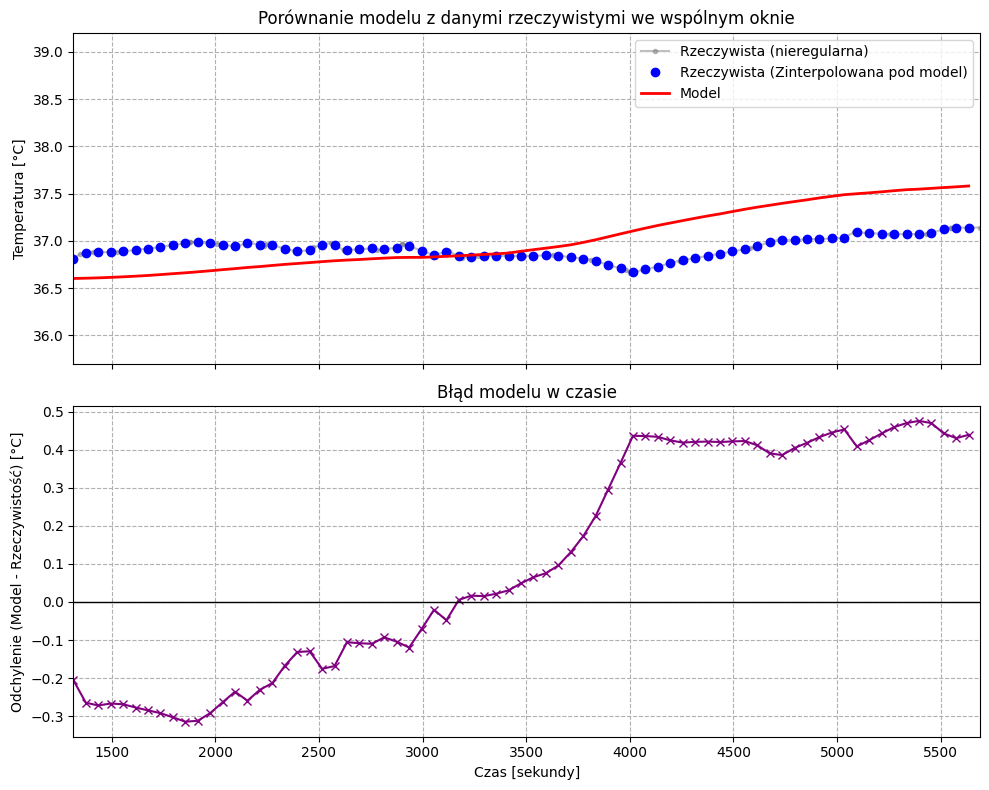

In [36]:
############################################################
################# BŁĄD TEMPERATURY CALEJ ##########################
# Załóżmy, że masz już przygotowane następujące zmienne z poprzednich kroków:
t_est= np.array(czasy_co_minute) #czas dla modelu (np. co 60 sekund)
temp_est = np.array(ct_list) # wyestymowana temperatura z modelu
t_act = np.array(df_temp['czas_sekundy']) # nieregularny czas rzeczywistej temperatury (np. z df_temp['czas_sekundy'])
temp_act = np.array(df_temp['temperatura']) # rzeczywista temperatura (np. z df_temp['temperatura'])

# Zamieniamy pandasowe serie na płaskie tablice numpy (dla wygody i szybkości interpolacji)
t_act = np.array(t_act)
temp_act = np.array(temp_act)

# ==========================================
# KROK 1: Wyznaczenie wspólnego okna czasowego
# ==========================================
# Wspólny start to późniejszy z dwóch startów, a koniec to wcześniejszy z dwóch końców
start_wspolny = max(t_est[0], t_act[0])
koniec_wspolny = min(t_est[-1], t_act[-1])

# Filtrujemy dane MODELU, aby mieściły się tylko we wspólnym oknie
maska_okna = (t_est >= start_wspolny) & (t_est <= koniec_wspolny)
t_est_wspolne = t_est[maska_okna]
temp_est_wspolne = temp_est[maska_okna]

# ==========================================
# KROK 2: Interpolacja danych rzeczywistych
# ==========================================
# Dla każdego punktu czasowego z modelu (t_est_wspolne), funkcja np.interp "szuka" 
# najbliższych punktów w nieregularnym czasie (t_act) i wylicza dokładną wartość rzeczywistą.
temp_act_zinterpolowane = np.interp(t_est_wspolne, t_act, temp_act)

# ==========================================
# KROK 3: Obliczenie odchyleń (błędów)
# ==========================================
# Teraz obie tablice mają DOKŁADNIE ten sam rozmiar i dotyczą tych samych sekund!
odchylenie_punktowe = temp_est_wspolne - temp_act_zinterpolowane

# Obliczenie popularnych metryk błędów
mae = np.mean(np.abs(odchylenie_punktowe))  # Średni błąd bezwzględny (Mean Absolute Error)
rmse = np.sqrt(np.mean(odchylenie_punktowe**2))  # Błąd średniokwadratowy (RMSE)

print(f"Średnie odchylenie bezwzględne (MAE): {mae:.2f} °C")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.2f} °C")
print(f"Maksymalne pomyłka modelu: {np.max(np.abs(odchylenie_punktowe)):.2f} °C")


# ==========================================
# KROK 4: Wizualizacja wyniku
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Wykres 1: Porównanie temperatur
ax1.plot(t_act, temp_act, color='gray', alpha=0.5, label='Rzeczywista (nieregularna)', marker='.')
ax1.plot(t_est_wspolne, temp_act_zinterpolowane, 'bo', label='Rzeczywista (Zinterpolowana pod model)')
ax1.plot(t_est_wspolne, temp_est_wspolne, 'r-', label='Model', linewidth=2)
ax1.set_ylabel('Temperatura [°C]')
ax1.legend()
ax1.grid(True, linestyle='--')
ax1.set_title('Porównanie modelu z danymi rzeczywistymi we wspólnym oknie')
ax1.set_xlim(left=start_wspolny, right=koniec_wspolny)
ax1.set_ylim(bottom=35.7, top=39.2)
# Wykres 2: Wykres błędu (Odchylenie)
ax2.plot(t_est_wspolne, odchylenie_punktowe, color='purple', marker='x', linestyle='-')
ax2.axhline(0, color='black', linestyle='-', linewidth=1) # Linia idealnego zera
ax2.set_xlabel('Czas [sekundy]')
ax2.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax2.grid(True, linestyle='--')
ax2.set_title('Błąd modelu w czasie')

plt.tight_layout()
plt.show()

Średnie odchylenie bezwzględne (MAE): 0.24 °C
Błąd średniokwadratowy (RMSE): 0.27 °C
Maksymalne pomyłka modelu: 0.40 °C


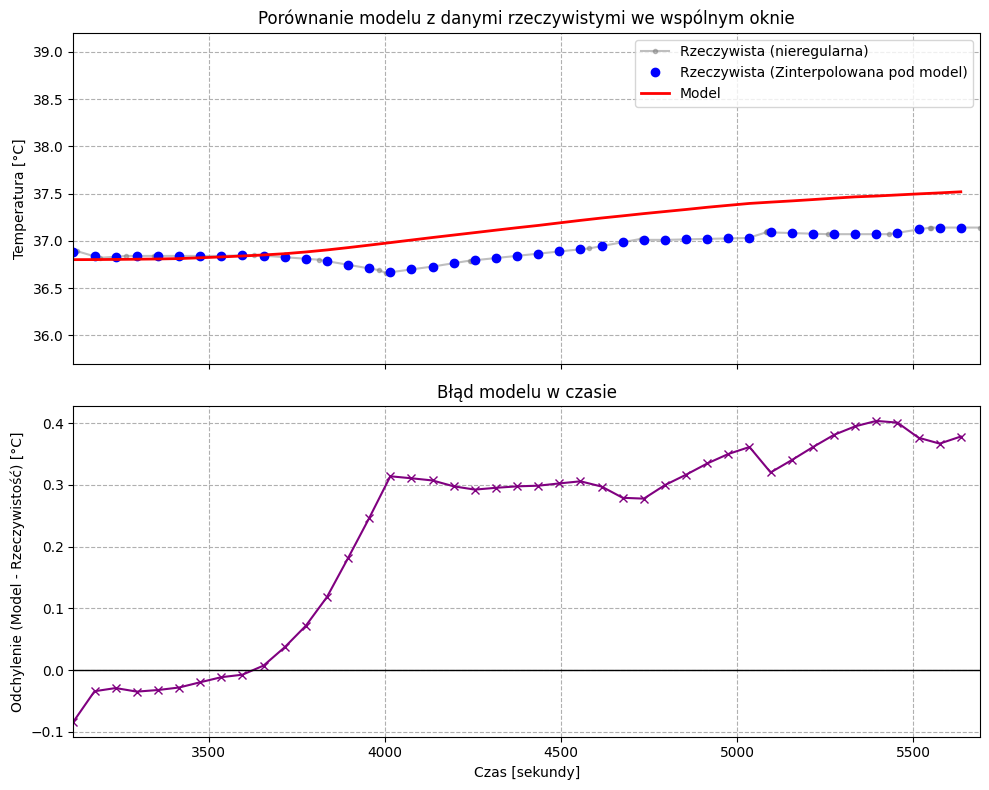

In [37]:
############################################################
################# BŁĄD TEMPERATURY WYSILKU ##########################
# Załóżmy, że masz już przygotowane następujące zmienne z poprzednich kroków:
t_est_wysilek= np.array(czasy_hr_wyselekcjonowane) #czas dla modelu (np. co 60 sekund)
temp_est_wysilek = np.array(ct_list_obciazenie) # wyestymowana temperatura z modelu
t_act_wysilek = np.array(df_temp['czas_sekundy']) # nieregularny czas rzeczywistej temperatury (np. z df_temp['czas_sekundy'])
temp_act_wysilek = np.array(df_temp['temperatura']) # rzeczywista temperatura (np. z df_temp['temperatura'])

# Zamieniamy pandasowe serie na płaskie tablice numpy (dla wygody i szybkości interpolacji)
t_act_wysilek = np.array(t_act_wysilek)
temp_act_wysilek = np.array(temp_act_wysilek)

# ==========================================
# KROK 1: Wyznaczenie wspólnego okna czasowego
# ==========================================
# Wspólny start to późniejszy z dwóch startów, a koniec to wcześniejszy z dwóch końców
start_wspolny_wysilek = max(t_est_wysilek[0], t_act_wysilek[0])
koniec_wspolny_wysilek = min(t_est_wysilek[-1], t_act_wysilek[-1])

# Filtrujemy dane MODELU, aby mieściły się tylko we wspólnym oknie
maska_okna = (t_est_wysilek >= start_wspolny_wysilek) & (t_est_wysilek <= koniec_wspolny_wysilek)
t_est_wspolne_wysilek = t_est_wysilek[maska_okna]
temp_est_wspolne_wysilek = temp_est_wysilek[maska_okna]

# ==========================================
# KROK 2: Interpolacja danych rzeczywistych
# ==========================================
# Dla każdego punktu czasowego z modelu (t_est_wspolne), funkcja np.interp "szuka" 
# najbliższych punktów w nieregularnym czasie (t_act_wysilek) i wylicza dokładną wartość rzeczywistą.
temp_act_zinterpolowane = np.interp(t_est_wspolne_wysilek, t_act_wysilek, temp_act_wysilek)

# ==========================================
# KROK 3: Obliczenie odchyleń (błędów)
# ==========================================
# Teraz obie tablice mają DOKŁADNIE ten sam rozmiar i dotyczą tych samych sekund!
odchylenie_punktowe_wysilek = temp_est_wspolne_wysilek - temp_act_zinterpolowane

# Obliczenie popularnych metryk błędów
mae = np.mean(np.abs(odchylenie_punktowe_wysilek))  # Średni błąd bezwzględny (Mean Absolute Error)
rmse = np.sqrt(np.mean(odchylenie_punktowe_wysilek**2))  # Błąd średniokwadratowy (RMSE)

print(f"Średnie odchylenie bezwzględne (MAE): {mae:.2f} °C")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.2f} °C")
print(f"Maksymalne pomyłka modelu: {np.max(np.abs(odchylenie_punktowe_wysilek)):.2f} °C")


# ==========================================
# KROK 4: Wizualizacja wyniku
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Wykres 1: Porównanie temperatur
ax1.plot(t_act_wysilek, temp_act_wysilek, color='gray', alpha=0.5, label='Rzeczywista (nieregularna)', marker='.')
ax1.plot(t_est_wspolne_wysilek, temp_act_zinterpolowane, 'bo', label='Rzeczywista (Zinterpolowana pod model)')
ax1.plot(t_est_wspolne_wysilek, temp_est_wspolne_wysilek, 'r-', label='Model', linewidth=2)
ax1.set_ylabel('Temperatura [°C]')
ax1.legend()
ax1.grid(True, linestyle='--')
ax1.set_title('Porównanie modelu z danymi rzeczywistymi we wspólnym oknie')
ax1.set_xlim(left=start_wspolny_wysilek, right=koniec_wspolny_wysilek)
ax1.set_ylim(bottom=35.7, top=39.2)
# Wykres 2: Wykres błędu (Odchylenie)
ax2.plot(t_est_wspolne_wysilek, odchylenie_punktowe_wysilek, color='purple', marker='x', linestyle='-')
ax2.axhline(0, color='black', linestyle='-', linewidth=1) # Linia idealnego zera
ax2.set_xlabel('Czas [sekundy]')
ax2.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax2.grid(True, linestyle='--')
ax2.set_title('Błąd modelu w czasie')

plt.tight_layout()
plt.show()

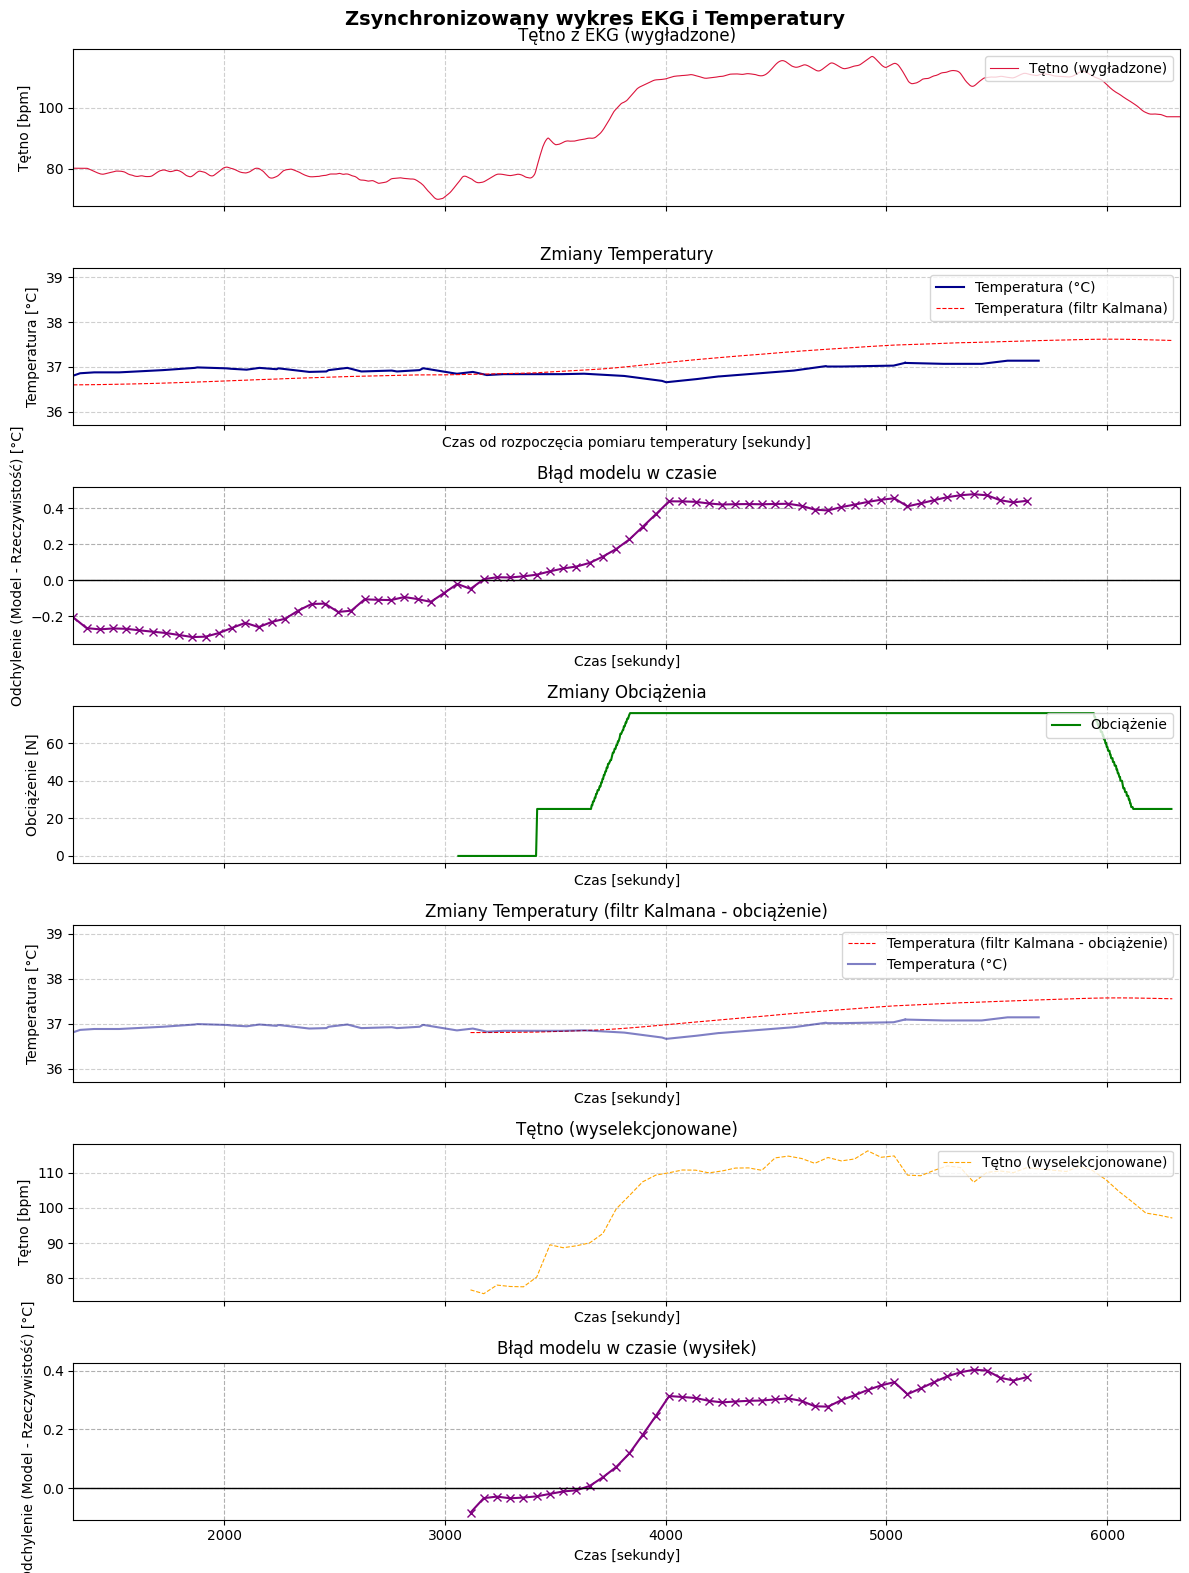

Temperatura wystartowała o: 2025-11-05 08:05:29.842149+00:00
EKG wystartowało o:         2025-11-05 08:27:25+00:00
EKG zaczęło się w 1315.158 sekundzie wykresu.


In [39]:

# ==========================================
# 4. WIZUALIZACJA NA JEDNYM WYKRESIE
# ==========================================

# Tworzymy dwa wykresy jeden pod drugim ze wspólną osią X (sharex=True)
fig, (ax1, ax2,ax2_5, ax3, ax4, ax5, ax6) = plt.subplots(7, 1, sharex=True, figsize=(12, 16))

# Wykres 1: Sygnał EKG
ax1.plot(ecg_times, hr_wygladzone, color='crimson', label='Tętno (wygładzone)', linewidth=0.8)
ax1.set_ylabel('Tętno [bpm]')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')
ax1.set_title('Tętno z EKG (wygładzone)')

# Wykres 2: Temperatura
ax2.plot(df_temp['czas_sekundy'], df_temp['temperatura'], color='darkblue', label='Temperatura (°C)')
ax2.plot(czasy_co_minute, ct_list, color='red', label='Temperatura (filtr Kalmana)', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Czas od rozpoczęcia pomiaru temperatury [sekundy]')
ax2.set_ylabel('Temperatura [°C]')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')
ax2.set_title('Zmiany Temperatury')
# Podsumowanie i dopasowanie układu
plt.suptitle('Zsynchronizowany wykres EKG i Temperatury', fontsize=14, fontweight='bold')
# Ustawia lewą krawędź wykresu na moment startu EKG
ax2.set_xlim(left=ecg_offset_seconds, right=max(ecg_times))  
ax2.set_ylim(bottom=35.7, top=39.2)

ax2_5.plot(t_est_wspolne, odchylenie_punktowe, color='purple', marker='x', linestyle='-')
ax2_5.axhline(0, color='black', linestyle='-', linewidth=1) # Linia idealnego zera
ax2_5.set_xlabel('Czas [sekundy]')
ax2_5.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax2_5.grid(True, linestyle='--')
ax2_5.set_title('Błąd modelu w czasie')



ax3.plot(df_obc_wynik['czas_sekundy'], df_obc_wynik['obciazenie'], color='green', label='Obciążenie')
ax3.set_xlabel('Czas [sekundy]')
ax3.set_ylabel('Obciążenie [N]')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(loc='upper right')
ax3.set_title('Zmiany Obciążenia')


ax4.plot(czasy_hr_wyselekcjonowane, ct_list_obciazenie, color='red', label='Temperatura (filtr Kalmana - obciążenie)', linewidth=0.8, linestyle='--')
ax4.plot(df_temp['czas_sekundy'], df_temp['temperatura'], color='darkblue', label='Temperatura (°C)', alpha=0.5)
ax4.set_xlabel('Czas [sekundy]')
ax4.set_ylabel('Temperatura [°C]')
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(loc='upper right')
ax4.set_title('Zmiany Temperatury (filtr Kalmana - obciążenie)')
ax4.set_ylim(bottom=35.7, top=39.2)

ax6.plot(t_est_wspolne_wysilek, odchylenie_punktowe_wysilek, color='purple', marker='x', linestyle='-')
ax6.axhline(0, color='black', linestyle='-', linewidth=1)
ax6.set_xlabel('Czas [sekundy]')
ax6.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax6.grid(True, linestyle='--')
ax6.set_title('Błąd modelu w czasie (wysiłek)')

ax5.plot(czasy_hr_wyselekcjonowane, hr_wyselekcjonowane, color='orange', label='Tętno (wyselekcjonowane)', linewidth=0.8, linestyle='--')
ax5.set_xlabel('Czas [sekundy]')
ax5.set_ylabel('Tętno [bpm]')
ax5.grid(True, linestyle='--', alpha=0.6)
ax5.legend(loc='upper right')
ax5.set_title('Tętno (wyselekcjonowane)')
plt.tight_layout()
plt.show()

# Opcjonalnie: Wyświetlenie informacji w konsoli
print(f"Temperatura wystartowała o: {t0}")
print(f"EKG wystartowało o:         {ecg_start_datetime}")
print(f"EKG zaczęło się w {ecg_offset_seconds:.3f} sekundzie wykresu.")

JM

In [41]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.stats import norm
# ==========================================
# 1. PARAMETRY STARTOWE I DANE WEJŚCIOWE
# ==========================================

# Ręcznie przypisany czas rozpoczęcia badania EKG
start_time = {
    'hour': 9,
    'minute': 44,
    'second': 6
}

# Częstotliwość próbkowania EKG
fs = 500  

# Symulacja Twoich danych EKG (zwykła lista Python)
dane_file = 'EKG-2025-11-06-09-44-06.csv'
dane = np.genfromtxt(dane_file, delimiter=',', skip_header=1)
ecg_signal = dane[:,1]


# ==========================================
# 2. PRZETWARZANIE TEMPERATURY (Plik .csv)
# ==========================================

# Wczytanie CSV (usecols=[0,1] ignoruje dodatkowy przecinek na końcu linii)
df_temp = pd.read_csv('2025-11-06_08-42-29+1_WYQKBC_temperature.csv', names=['surowy_czas', 'temperatura'], usecols=[0, 1])
df_temp['surowy_czas'] = df_temp['surowy_czas'].str.strip()

# Konwersja czasu temperatury na obiekty Datetime (używamy utc=True dla obsługi strefy +1)
df_temp['datetime'] = pd.to_datetime(df_temp['surowy_czas'], utc=True)

# Definiujemy punkt zero (t0) jako początek pomiaru temperatury
t0 = df_temp['datetime'].iloc[0]

# Obliczamy czas względny w sekundach dla temperatury
df_temp['czas_sekundy'] = (df_temp['datetime'] - t0).dt.total_seconds()

# ==========================================
# 3. SYNCHRONIZACJA I PRZETWARZANIE EKG
# ==========================================

# Wyciągamy datę (np. "2025-11-05") z pierwszego wiersza temperatury
pierwszy_wiersz_czas = df_temp['surowy_czas'].iloc[0]
data_part = pierwszy_wiersz_czas.split('T')[0]

# Wyciągamy końcówkę strefy czasowej (np. "+1" lub "-02:00")
tz_suffix = ""
if 'T' in pierwszy_wiersz_czas:
    time_part = pierwszy_wiersz_czas.split('T')[1]
    if '+' in time_part:
        tz_suffix = '+' + time_part.split('+')[-1]
    elif '-' in time_part:
        tz_suffix = '-' + time_part.split('-')[-1]

# Budujemy pełny ciąg tekstowy ISO dla startu EKG na podstawie słownika start_time
ecg_start_iso = f"{data_part}T{start_time['hour']:02d}:{start_time['minute']:02d}:{start_time['second']:02d}{tz_suffix}"
ecg_start_datetime = pd.to_datetime(ecg_start_iso, utc=True)

# Obliczamy przesunięcie: w której sekundzie (względem temperatury) wystartowało EKG
ecg_offset_seconds = (ecg_start_datetime - t0).total_seconds()

# Generujemy oś czasu dla EKG w sekundach (co 1/500 sekundy od momentu przesunięcia)
liczba_probek_ekg = len(ecg_signal)
ecg_times = ecg_offset_seconds + (np.arange(liczba_probek_ekg) / fs)


# Przetwarzanie sygnału - automatyczna filtracja, czyszczenie i ekstrakcja cech
signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)

# `signals` to ramka danych (pandas DataFrame), która zawiera wyliczone tętno punkt po punkcie
hr_signal = signals["ECG_Rate"]
rozmiar_okna = 30000

# 1. Filtr medianowy - rewelacyjnie usuwa ostre, pojedyncze "szpilki" z wykresu
# Parametr center=True sprawia, że wykres nie przesunie się w prawo
hr_bez_szpilek = hr_signal.rolling(window=rozmiar_okna, center=True).median()

# 2. Średnia krocząca - wygładza główny trend (możesz nałożyć ją na wynik mediany)
hr_wygladzone = hr_bez_szpilek.rolling(window=rozmiar_okna, center=True).mean()
hr_wygladzone = hr_wygladzone.fillna(method='bfill').fillna(method='ffill')


# Obliczamy, co ile próbek wypada dokładnie 1 minuta
krok_1_minuta = 60 * fs  # 60 sekund * 500 Hz = 30000 próbek

# Wyciągamy co 30000-ną próbkę z wektora czasu EKG
czasy_co_minute = ecg_times[::krok_1_minuta]

# Wyciągamy odpowiadające im wartości wygładzonego tętna
# (Zakładam, że Twoja zmienna nazywa się hr_wygladzone)
#hr_co_minute = hr_wygladzone[::krok_1_minuta] # Używamy .iloc jeśli to seria Pandas, lub po prostu [::krok] dla zwykłej tablicy NumPy
hr_co_minute = hr_wygladzone.iloc[::krok_1_minuta].to_numpy()

b0=-7887.1
b1=384.4286
b2=-4.5714
ct0=36.6
v0=0
a1=1
a0=0
y=0.022
s=18.88
f=norm.rvs(0,y)
ctm1=ct0
vm1=v0


def filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_signal):
    v_list=[]
    ct_list=[]
    for i in range(len(hr_signal)):
        ctp=a1*ctm1+a0
        vp=a1**2*vm1+y**2
        #f=np.random.normal(loc=0, scale=y)
        c=2*b2*ctp+b1
        k=(vp*c)/(vp*c**2+s**2)
        ct=ctp+k*(hr_signal[i]-(b2*ctp**2+b1*ctp+b0))
        v=(1-k*c)*vp
        ct_list.append(ct)
        v_list.append(v)
        ctm1=ct
        vm1=v
    return ct_list, v_list
ct_list, v_list=filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_co_minute)

C:\Users\micha\AppData\Local\Temp\ipykernel_37536\1310187128.py:86: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr_wygladzone = hr_wygladzone.fillna(method='bfill').fillna(method='ffill')


In [42]:
#############################################################################################
################################     DANE DO WYSIŁKU     ########################################
dane_file_wysilek = '06_11_2025_W_2.csv'
df_obc = pd.read_csv(dane_file_wysilek, sep=';', names=['surowy_czas', 'obciazenie'])

# Opcjonalne czyszczenie białych znaków
df_obc['surowy_czas'] = df_obc['surowy_czas'].str.strip()

# 2. Rozbicie formatu "MM:SS:00" na 3 osobne kolumny za pomocą dwukropka
# expand=True sprawia, że wynik to nowa tabelka z 3 kolumnami (indeksy 0, 1, 2)
czas_rozbity = df_obc['surowy_czas'].str.split(':', expand=True)

# 3. Konwersja tekstu na liczby
minuty = czas_rozbity[0].astype(int)
sekundy = czas_rozbity[1].astype(int)

# Jeśli ostatnie '00' to setne części sekundy, możemy je też wyciągnąć 
# (jeśli są tam zawsze same zera, to nic nie zmieni w wyniku)
ulamki = czas_rozbity[2].astype(float) / 100 

# 4. Obliczenie czasu w samych sekundach
df_obc['czas_sekundy'] = (minuty * 60) + sekundy + ulamki+ecg_offset_seconds

# Podgląd - wyciągamy tylko to co nas interesuje
df_obc_wynik = df_obc[['czas_sekundy', 'obciazenie']]

obciazenie_start_time = df_obc_wynik['czas_sekundy'].iloc[0]

In [43]:
#######################################################################
######################    Kalman dla obciążenia #######################
########################################################################
# 1. Tworzymy MASKĘ. 
# Wynikiem będzie lista wartości True/False (Prawda/Fałsz).
# True tam, gdzie czas z wektora 'czasy_co_minute' jest >= czasu rozpoczęcia obciążenia
maska_obciazenia = czasy_co_minute >= obciazenie_start_time

# 2. Nakładamy maskę na nasze wektory!
# Wyciągamy czasy HR oraz samo HR, ale tylko z momentów "True"
czasy_hr_wyselekcjonowane = czasy_co_minute[maska_obciazenia]
hr_wyselekcjonowane = hr_co_minute[maska_obciazenia]
# 3. Teraz możemy zastosować filtr Kalmana tylko do tych wyselekcjonowanych punktów
ctm1=36.8
ct_list_obciazenie, v_list_obciazenie = filtr(ctm1, vm1, b0, b1, b2, a0, a1, y, s, hr_wyselekcjonowane)

Średnie odchylenie bezwzględne (MAE): 0.36 °C
Błąd średniokwadratowy (RMSE): 0.45 °C
Maksymalne pomyłka modelu: 0.89 °C


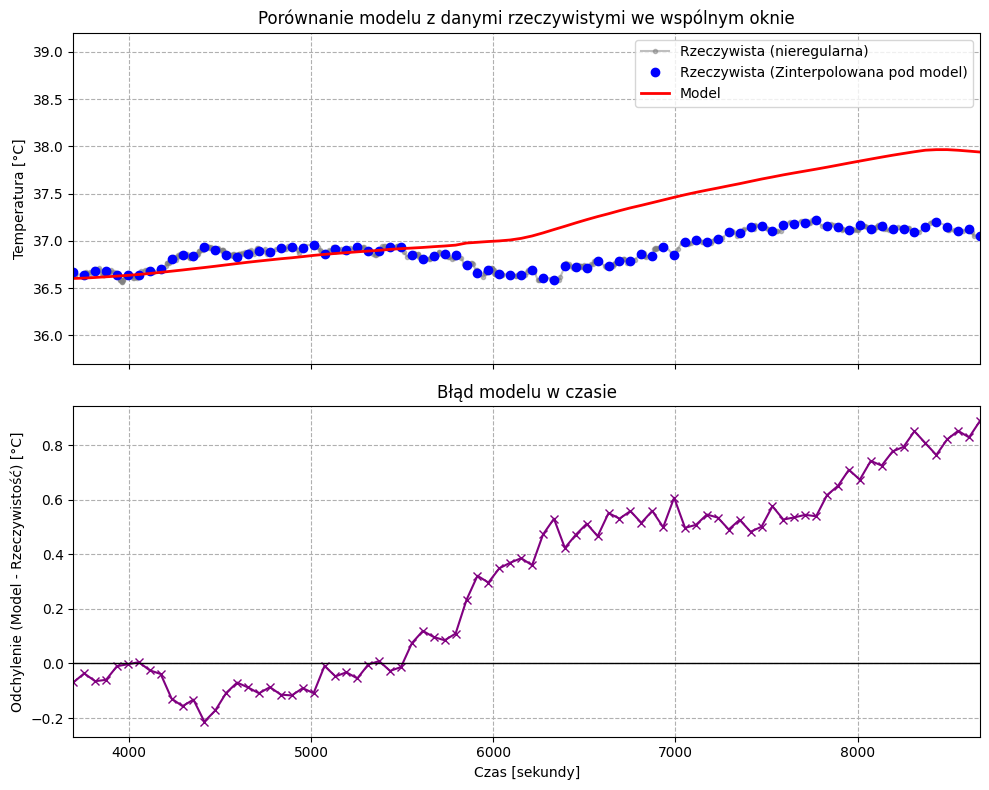

In [44]:
############################################################
################# BŁĄD TEMPERATURY CALEJ ##########################
# Załóżmy, że masz już przygotowane następujące zmienne z poprzednich kroków:
t_est= np.array(czasy_co_minute) #czas dla modelu (np. co 60 sekund)
temp_est = np.array(ct_list) # wyestymowana temperatura z modelu
t_act = np.array(df_temp['czas_sekundy']) # nieregularny czas rzeczywistej temperatury (np. z df_temp['czas_sekundy'])
temp_act = np.array(df_temp['temperatura']) # rzeczywista temperatura (np. z df_temp['temperatura'])

# Zamieniamy pandasowe serie na płaskie tablice numpy (dla wygody i szybkości interpolacji)
t_act = np.array(t_act)
temp_act = np.array(temp_act)

# ==========================================
# KROK 1: Wyznaczenie wspólnego okna czasowego
# ==========================================
# Wspólny start to późniejszy z dwóch startów, a koniec to wcześniejszy z dwóch końców
start_wspolny = max(t_est[0], t_act[0])
koniec_wspolny = min(t_est[-1], t_act[-1])

# Filtrujemy dane MODELU, aby mieściły się tylko we wspólnym oknie
maska_okna = (t_est >= start_wspolny) & (t_est <= koniec_wspolny)
t_est_wspolne = t_est[maska_okna]
temp_est_wspolne = temp_est[maska_okna]

# ==========================================
# KROK 2: Interpolacja danych rzeczywistych
# ==========================================
# Dla każdego punktu czasowego z modelu (t_est_wspolne), funkcja np.interp "szuka" 
# najbliższych punktów w nieregularnym czasie (t_act) i wylicza dokładną wartość rzeczywistą.
temp_act_zinterpolowane = np.interp(t_est_wspolne, t_act, temp_act)

# ==========================================
# KROK 3: Obliczenie odchyleń (błędów)
# ==========================================
# Teraz obie tablice mają DOKŁADNIE ten sam rozmiar i dotyczą tych samych sekund!
odchylenie_punktowe = temp_est_wspolne - temp_act_zinterpolowane

# Obliczenie popularnych metryk błędów
mae = np.mean(np.abs(odchylenie_punktowe))  # Średni błąd bezwzględny (Mean Absolute Error)
rmse = np.sqrt(np.mean(odchylenie_punktowe**2))  # Błąd średniokwadratowy (RMSE)

print(f"Średnie odchylenie bezwzględne (MAE): {mae:.2f} °C")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.2f} °C")
print(f"Maksymalne pomyłka modelu: {np.max(np.abs(odchylenie_punktowe)):.2f} °C")


# ==========================================
# KROK 4: Wizualizacja wyniku
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Wykres 1: Porównanie temperatur
ax1.plot(t_act, temp_act, color='gray', alpha=0.5, label='Rzeczywista (nieregularna)', marker='.')
ax1.plot(t_est_wspolne, temp_act_zinterpolowane, 'bo', label='Rzeczywista (Zinterpolowana pod model)')
ax1.plot(t_est_wspolne, temp_est_wspolne, 'r-', label='Model', linewidth=2)
ax1.set_ylabel('Temperatura [°C]')
ax1.legend()
ax1.grid(True, linestyle='--')
ax1.set_title('Porównanie modelu z danymi rzeczywistymi we wspólnym oknie')
ax1.set_xlim(left=start_wspolny, right=koniec_wspolny)
ax1.set_ylim(bottom=35.7, top=39.2)
# Wykres 2: Wykres błędu (Odchylenie)
ax2.plot(t_est_wspolne, odchylenie_punktowe, color='purple', marker='x', linestyle='-')
ax2.axhline(0, color='black', linestyle='-', linewidth=1) # Linia idealnego zera
ax2.set_xlabel('Czas [sekundy]')
ax2.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax2.grid(True, linestyle='--')
ax2.set_title('Błąd modelu w czasie')

plt.tight_layout()
plt.show()

Średnie odchylenie bezwzględne (MAE): 0.40 °C
Błąd średniokwadratowy (RMSE): 0.45 °C
Maksymalne pomyłka modelu: 0.83 °C


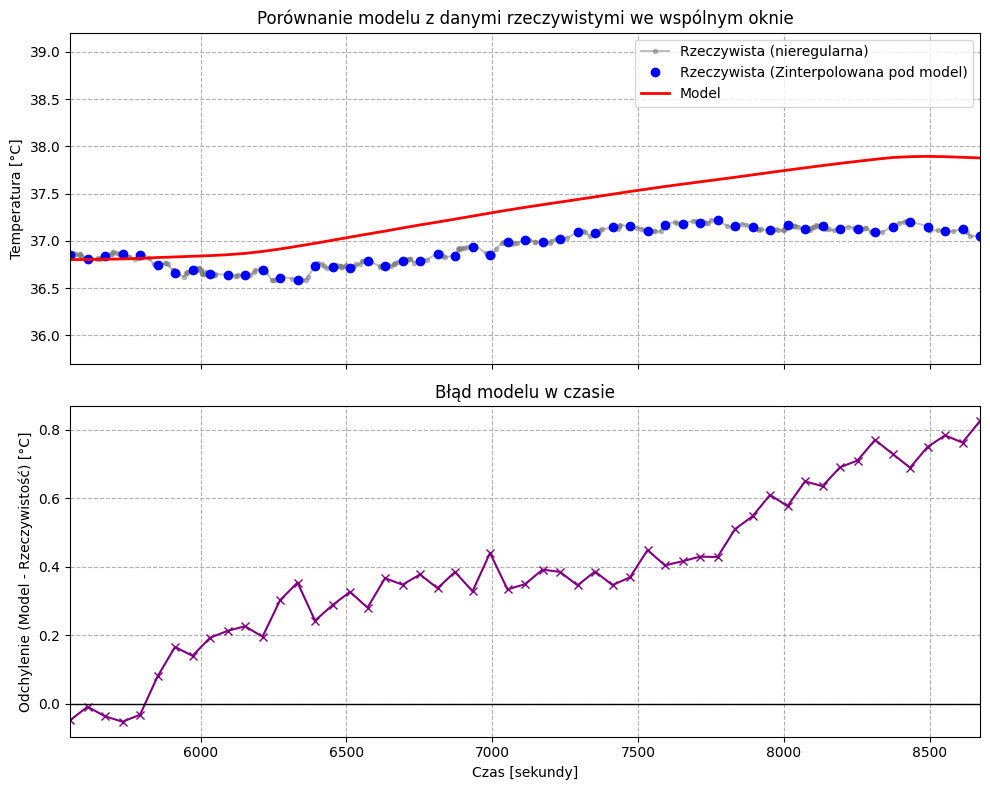

In [45]:
############################################################
################# BŁĄD TEMPERATURY WYSILKU ##########################
# Załóżmy, że masz już przygotowane następujące zmienne z poprzednich kroków:
t_est_wysilek= np.array(czasy_hr_wyselekcjonowane) #czas dla modelu (np. co 60 sekund)
temp_est_wysilek = np.array(ct_list_obciazenie) # wyestymowana temperatura z modelu
t_act_wysilek = np.array(df_temp['czas_sekundy']) # nieregularny czas rzeczywistej temperatury (np. z df_temp['czas_sekundy'])
temp_act_wysilek = np.array(df_temp['temperatura']) # rzeczywista temperatura (np. z df_temp['temperatura'])

# Zamieniamy pandasowe serie na płaskie tablice numpy (dla wygody i szybkości interpolacji)
t_act_wysilek = np.array(t_act_wysilek)
temp_act_wysilek = np.array(temp_act_wysilek)

# ==========================================
# KROK 1: Wyznaczenie wspólnego okna czasowego
# ==========================================
# Wspólny start to późniejszy z dwóch startów, a koniec to wcześniejszy z dwóch końców
start_wspolny_wysilek = max(t_est_wysilek[0], t_act_wysilek[0])
koniec_wspolny_wysilek = min(t_est_wysilek[-1], t_act_wysilek[-1])

# Filtrujemy dane MODELU, aby mieściły się tylko we wspólnym oknie
maska_okna = (t_est_wysilek >= start_wspolny_wysilek) & (t_est_wysilek <= koniec_wspolny_wysilek)
t_est_wspolne_wysilek = t_est_wysilek[maska_okna]
temp_est_wspolne_wysilek = temp_est_wysilek[maska_okna]

# ==========================================
# KROK 2: Interpolacja danych rzeczywistych
# ==========================================
# Dla każdego punktu czasowego z modelu (t_est_wspolne), funkcja np.interp "szuka" 
# najbliższych punktów w nieregularnym czasie (t_act_wysilek) i wylicza dokładną wartość rzeczywistą.
temp_act_zinterpolowane = np.interp(t_est_wspolne_wysilek, t_act_wysilek, temp_act_wysilek)

# ==========================================
# KROK 3: Obliczenie odchyleń (błędów)
# ==========================================
# Teraz obie tablice mają DOKŁADNIE ten sam rozmiar i dotyczą tych samych sekund!
odchylenie_punktowe_wysilek = temp_est_wspolne_wysilek - temp_act_zinterpolowane

# Obliczenie popularnych metryk błędów
mae = np.mean(np.abs(odchylenie_punktowe_wysilek))  # Średni błąd bezwzględny (Mean Absolute Error)
rmse = np.sqrt(np.mean(odchylenie_punktowe_wysilek**2))  # Błąd średniokwadratowy (RMSE)

print(f"Średnie odchylenie bezwzględne (MAE): {mae:.2f} °C")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.2f} °C")
print(f"Maksymalne pomyłka modelu: {np.max(np.abs(odchylenie_punktowe_wysilek)):.2f} °C")


# ==========================================
# KROK 4: Wizualizacja wyniku
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Wykres 1: Porównanie temperatur
ax1.plot(t_act_wysilek, temp_act_wysilek, color='gray', alpha=0.5, label='Rzeczywista (nieregularna)', marker='.')
ax1.plot(t_est_wspolne_wysilek, temp_act_zinterpolowane, 'bo', label='Rzeczywista (Zinterpolowana pod model)')
ax1.plot(t_est_wspolne_wysilek, temp_est_wspolne_wysilek, 'r-', label='Model', linewidth=2)
ax1.set_ylabel('Temperatura [°C]')
ax1.legend()
ax1.grid(True, linestyle='--')
ax1.set_title('Porównanie modelu z danymi rzeczywistymi we wspólnym oknie')
ax1.set_xlim(left=start_wspolny_wysilek, right=koniec_wspolny_wysilek)
ax1.set_ylim(bottom=35.7, top=39.2)
# Wykres 2: Wykres błędu (Odchylenie)
ax2.plot(t_est_wspolne_wysilek, odchylenie_punktowe_wysilek, color='purple', marker='x', linestyle='-')
ax2.axhline(0, color='black', linestyle='-', linewidth=1) # Linia idealnego zera
ax2.set_xlabel('Czas [sekundy]')
ax2.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax2.grid(True, linestyle='--')
ax2.set_title('Błąd modelu w czasie')

plt.tight_layout()
plt.show()

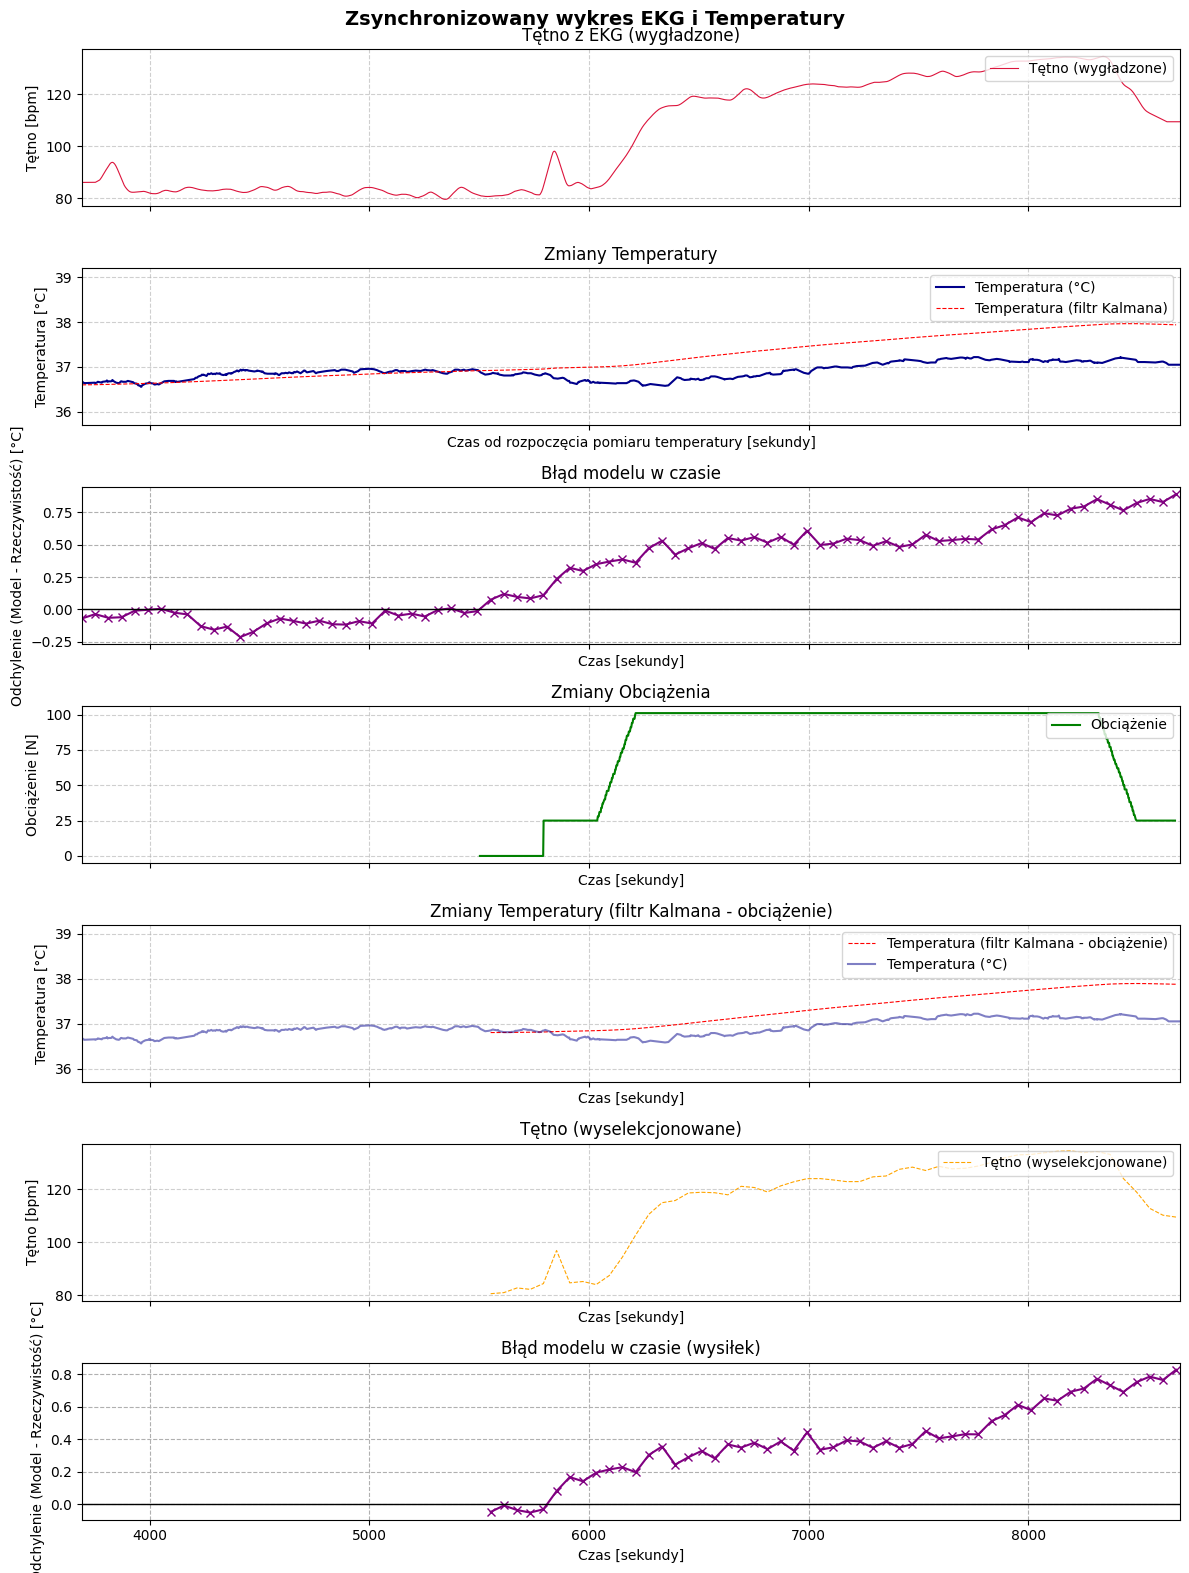

Temperatura wystartowała o: 2025-11-06 07:42:33.365006+00:00
EKG wystartowało o:         2025-11-06 08:44:06+00:00
EKG zaczęło się w 3692.635 sekundzie wykresu.


In [46]:

# ==========================================
# 4. WIZUALIZACJA NA JEDNYM WYKRESIE
# ==========================================

# Tworzymy dwa wykresy jeden pod drugim ze wspólną osią X (sharex=True)
fig, (ax1, ax2,ax2_5, ax3, ax4, ax5, ax6) = plt.subplots(7, 1, sharex=True, figsize=(12, 16))

# Wykres 1: Sygnał EKG
ax1.plot(ecg_times, hr_wygladzone, color='crimson', label='Tętno (wygładzone)', linewidth=0.8)
ax1.set_ylabel('Tętno [bpm]')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')
ax1.set_title('Tętno z EKG (wygładzone)')

# Wykres 2: Temperatura
ax2.plot(df_temp['czas_sekundy'], df_temp['temperatura'], color='darkblue', label='Temperatura (°C)')
ax2.plot(czasy_co_minute, ct_list, color='red', label='Temperatura (filtr Kalmana)', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Czas od rozpoczęcia pomiaru temperatury [sekundy]')
ax2.set_ylabel('Temperatura [°C]')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')
ax2.set_title('Zmiany Temperatury')
# Podsumowanie i dopasowanie układu
plt.suptitle('Zsynchronizowany wykres EKG i Temperatury', fontsize=14, fontweight='bold')
# Ustawia lewą krawędź wykresu na moment startu EKG
ax2.set_xlim(left=ecg_offset_seconds, right=max(ecg_times))  
ax2.set_ylim(bottom=35.7, top=39.2)

ax2_5.plot(t_est_wspolne, odchylenie_punktowe, color='purple', marker='x', linestyle='-')
ax2_5.axhline(0, color='black', linestyle='-', linewidth=1) # Linia idealnego zera
ax2_5.set_xlabel('Czas [sekundy]')
ax2_5.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax2_5.grid(True, linestyle='--')
ax2_5.set_title('Błąd modelu w czasie')



ax3.plot(df_obc_wynik['czas_sekundy'], df_obc_wynik['obciazenie'], color='green', label='Obciążenie')
ax3.set_xlabel('Czas [sekundy]')
ax3.set_ylabel('Obciążenie [N]')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(loc='upper right')
ax3.set_title('Zmiany Obciążenia')


ax4.plot(czasy_hr_wyselekcjonowane, ct_list_obciazenie, color='red', label='Temperatura (filtr Kalmana - obciążenie)', linewidth=0.8, linestyle='--')
ax4.plot(df_temp['czas_sekundy'], df_temp['temperatura'], color='darkblue', label='Temperatura (°C)', alpha=0.5)
ax4.set_xlabel('Czas [sekundy]')
ax4.set_ylabel('Temperatura [°C]')
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(loc='upper right')
ax4.set_title('Zmiany Temperatury (filtr Kalmana - obciążenie)')
ax4.set_ylim(bottom=35.7, top=39.2)

ax6.plot(t_est_wspolne_wysilek, odchylenie_punktowe_wysilek, color='purple', marker='x', linestyle='-')
ax6.axhline(0, color='black', linestyle='-', linewidth=1)
ax6.set_xlabel('Czas [sekundy]')
ax6.set_ylabel('Odchylenie (Model - Rzeczywistość) [°C]')
ax6.grid(True, linestyle='--')
ax6.set_title('Błąd modelu w czasie (wysiłek)')

ax5.plot(czasy_hr_wyselekcjonowane, hr_wyselekcjonowane, color='orange', label='Tętno (wyselekcjonowane)', linewidth=0.8, linestyle='--')
ax5.set_xlabel('Czas [sekundy]')
ax5.set_ylabel('Tętno [bpm]')
ax5.grid(True, linestyle='--', alpha=0.6)
ax5.legend(loc='upper right')
ax5.set_title('Tętno (wyselekcjonowane)')
plt.tight_layout()
plt.show()

# Opcjonalnie: Wyświetlenie informacji w konsoli
print(f"Temperatura wystartowała o: {t0}")
print(f"EKG wystartowało o:         {ecg_start_datetime}")
print(f"EKG zaczęło się w {ecg_offset_seconds:.3f} sekundzie wykresu.")